In [96]:
from pybaseball import statcast_single_game, playerid_reverse_lookup
import matplotlib.pyplot as plt
import statsapi as MLB_API
import pandas as pd

## Get Team and Game Info

In [97]:
print("lookup team")
tor = MLB_API.lookup_team("tor")
last_game_id = MLB_API.last_game(tor[0]['id'])
game_info:pd.DataFrame = statcast_single_game(last_game_id)
if not game_info.empty:
    print("got game👍")
else:
    print("get game failed :(")
    raise RuntimeError("failed to get game")

lookup team
got game👍


c:\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)


## Game Info

In [98]:
# keys = game_info.keys()

# with open('game_info_keys.txt', 'w') as f:
#     for key in keys:
#         f.write(f"{key}\n")
        
home_team = game_info.iloc[0]['home_team']
away_team = game_info.iloc[0]['away_team']

print(f"Game Date: {game_info.iloc[0]['game_date']}")
print(f"{away_team} @ {home_team}")
print(f"{game_info['post_away_score'].max()} - {game_info['post_home_score'].max()}")
if not game_info.iloc[0]['inning'] == 9:
    print(f"Extra innings - ({game_info.iloc[0]['inning']})")

Game Date: 2026-04-04 00:00:00
TOR @ CWS
3 - 6


## Batter Info

In [99]:
batters = game_info['batter'].unique().tolist()

print(f"Total Unique Batters: {len(batters)}")

names:pd.DataFrame = playerid_reverse_lookup(batters, key_type='mlbam')
batters:tuple[int, str, str] = list(zip(names['key_mlbam'], names['name_first'], names['name_last']))

batter_info = []

for batter in batters:
    woba = float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_woba_using_speedangle'].mean(), 3))
    xslg = float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_slg_using_speedangle'].mean(), 3))
    if pd.isna(woba):
        woba = 0
    if pd.isna(xslg):
        xslg = 0
    b_data = {
        'id': batter[0],
        'first_name': batter[1].capitalize(),
        'last_name': batter[2].capitalize(),
        'total_estimated_woba': float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_woba_using_speedangle'].sum(), 3)),
        'total_estimated_slg': float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_slg_using_speedangle'].sum(), 3)),
        'total_wops': float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_woba_using_speedangle'].sum(), 3)) +
        float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_slg_using_speedangle'].sum(), 3)),
        'home_team': game_info.loc[game_info['batter'] == batter[0], 'inning_topbot'].iloc[0] == 'Bot',
        'woba':woba,
        'xslg':xslg,
        'wops': round(woba + xslg, 3)
    }
    batter_info.append(b_data)
    print(f"---{b_data['last_name']}, {b_data['first_name']}---")
    print(f"Team = {home_team if b_data['home_team'] else away_team}")
    print(f"Estimated times reaching base: {b_data['total_estimated_woba']}")
    print(f"Estimated total bases: {b_data['total_estimated_slg']}")
    print(f"Total wOPS: {b_data['total_wops']}")
    print(f'wOBA: {b_data['woba']}')
    print(f'xSLG: {b_data['xslg']}')
    print(f'wOPS: {b_data['wops']}')

Total Unique Batters: 22
---Schneider, Davis---
Team = TOR
Estimated times reaching base: 1.379
Estimated total bases: 0.883
Total wOPS: 2.262
wOBA: 0.46
xSLG: 0.442
wOPS: 0.902
---Lukes, Nathan---
Team = TOR
Estimated times reaching base: 0.07
Estimated total bases: 0.054
Total wOPS: 0.124
wOBA: 0.035
xSLG: 0.054
wOPS: 0.089
---Barger, Addison---
Team = TOR
Estimated times reaching base: 0.7
Estimated total bases: 0.0
Total wOPS: 0.7
wOBA: 0.7
xSLG: 0
wOPS: 0.7
---Peters, Tristan---
Team = CWS
Estimated times reaching base: 0.254
Estimated total bases: 0.273
Total wOPS: 0.527
wOBA: 0.085
xSLG: 0.136
wOPS: 0.221
---Benintendi, Andrew---
Team = CWS
Estimated times reaching base: 0.428
Estimated total bases: 0.508
Total wOPS: 0.9359999999999999
wOBA: 0.428
xSLG: 0.508
wOPS: 0.936
---Meidroth, Chase---
Team = CWS
Estimated times reaching base: 0.416
Estimated total bases: 0.565
Total wOPS: 0.9809999999999999
wOBA: 0.104
xSLG: 0.141
wOPS: 0.245
---Clement, Ernie---
Team = TOR
Estimated tim

## Team Splits and Game Predictions

In [100]:
home_info = []
away_info = []
for batter in batter_info:
    if batter['home_team']:
        home_info.append(batter)
    else:
        away_info.append(batter)

def print_team_info(team_info:list, home_away:bool) -> None:
    print(f'-----{home_team if home_away else away_team} Team Info-----')
    print(f'Estimated times reaching base: {sum(batter['total_estimated_woba'] for batter in team_info)}')
    print(f'Estimated bases: {sum(batter['total_estimated_slg'] for batter in team_info)}')
    print(f'Team wOBA: {round(sum(batter['woba'] for batter in team_info) / len(team_info), 3)}')
    print(f'Team xSLG: {round(sum(batter['xslg'] for batter in team_info) / len(team_info), 3)}')
    print(f'Team wOPS: {round(sum(batter['wops'] for batter in team_info) / len(team_info), 3)}')
    print('\n')

print_team_info(home_info, True)
print_team_info(away_info, False)

print('-----Game Analysis-----')
winometer = sum(batter['total_estimated_slg'] for batter in home_info) / (sum(batter['total_estimated_slg'] for batter in home_info) + sum(batter['total_estimated_slg'] for batter in away_info))
print(f'{home_team} Deserve-to-Win-O-Meter: {round(winometer, 4) * 100}%')
print(f'{away_team} Deserve-to-Win-O-Meter: {round(1 - winometer, 4) * 100}%')

-----CWS Team Info-----
Estimated times reaching base: 8.759
Estimated bases: 9.442
Team wOBA: 0.302
Team xSLG: 0.537
Team wOPS: 0.839


-----TOR Team Info-----
Estimated times reaching base: 12.636
Estimated bases: 14.759
Team wOBA: 0.419
Team xSLG: 0.515
Team wOPS: 0.934


-----Game Analysis-----
CWS Deserve-to-Win-O-Meter: 39.01%
TOR Deserve-to-Win-O-Meter: 60.99%


## Visualizations

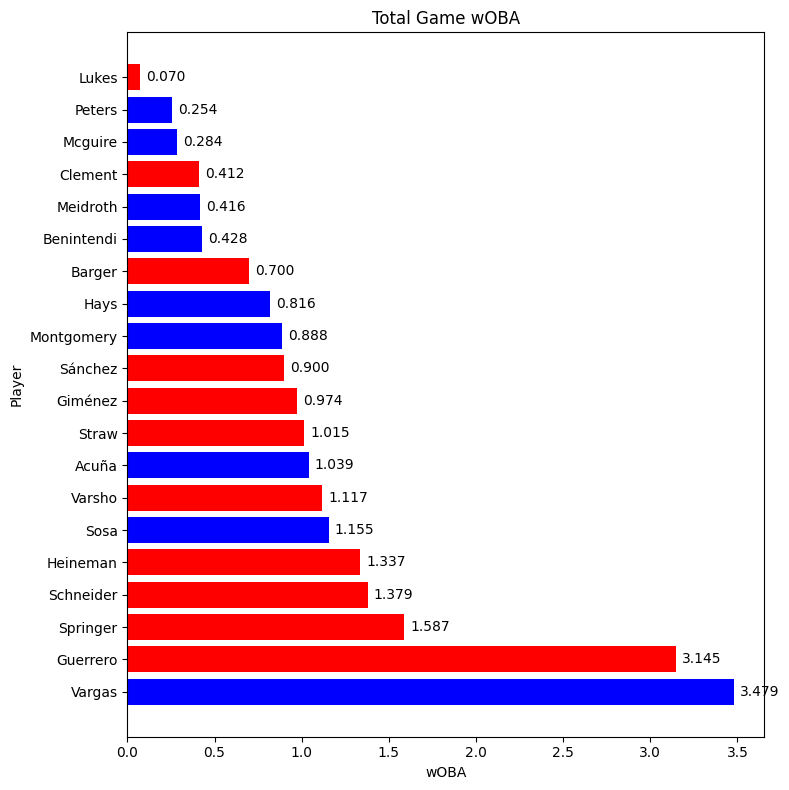

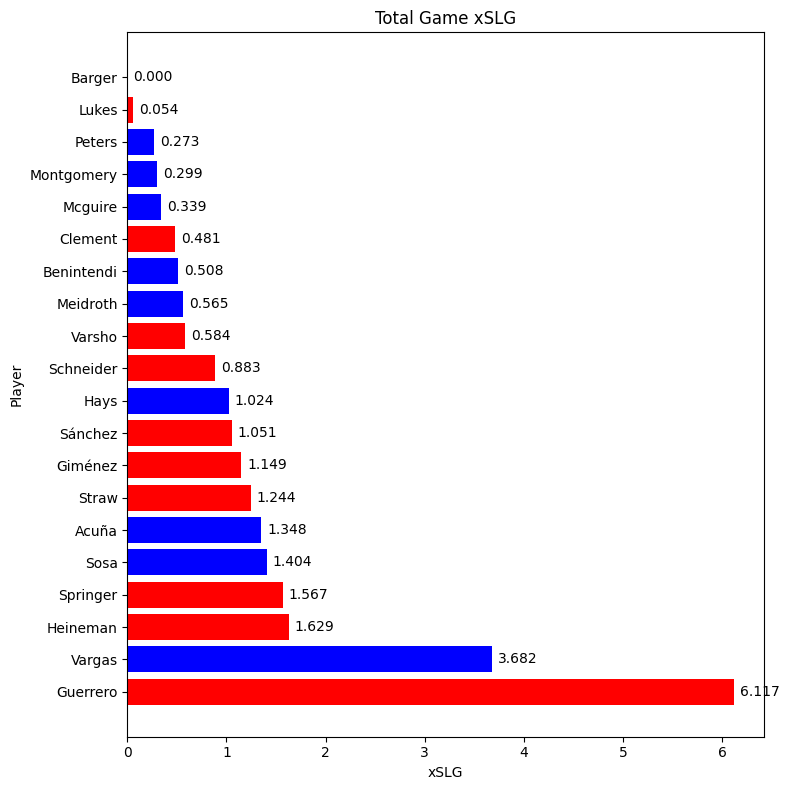

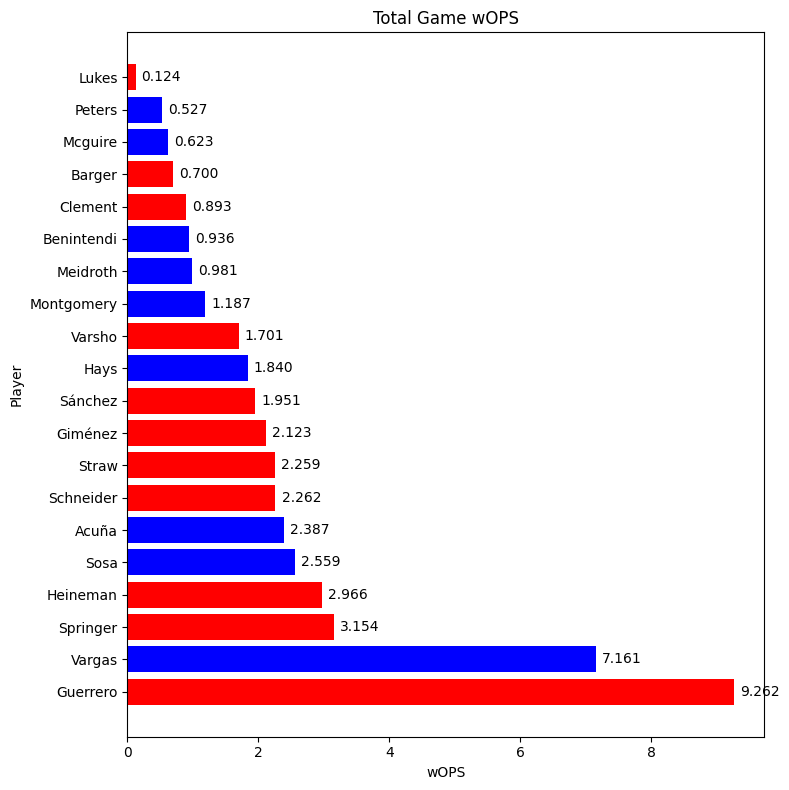

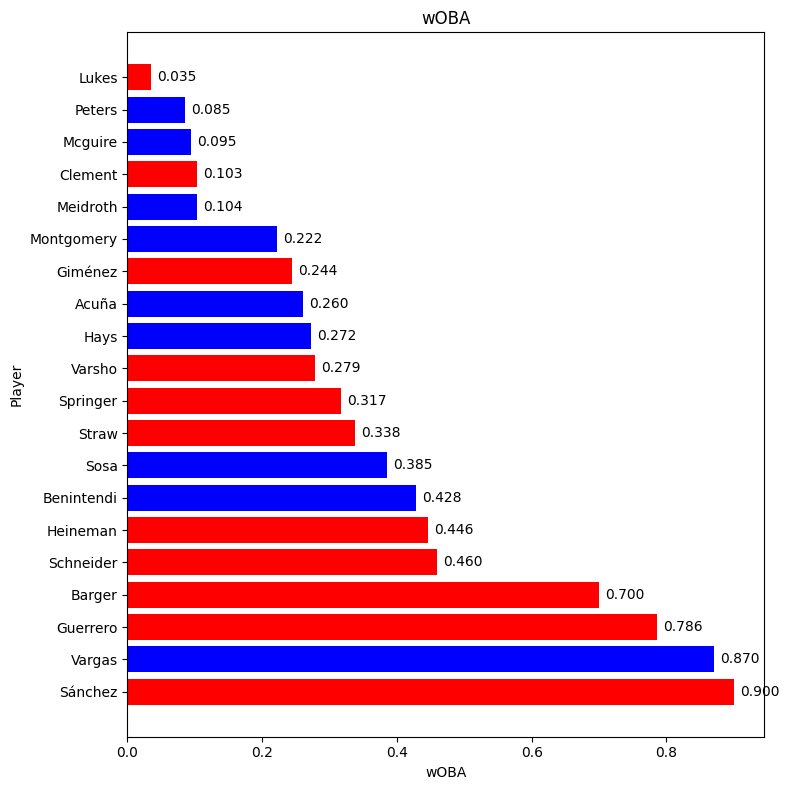

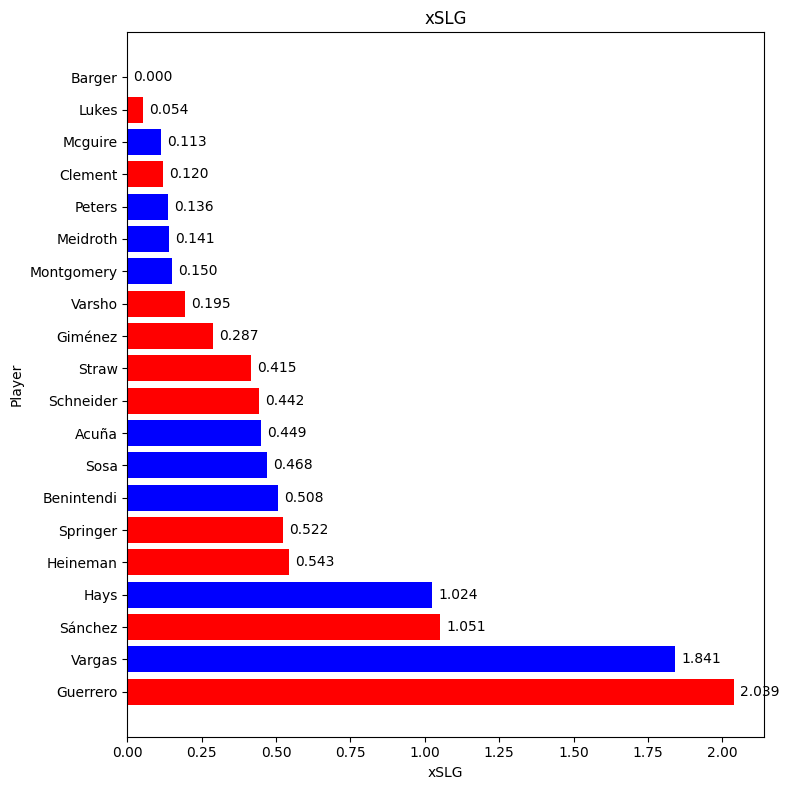

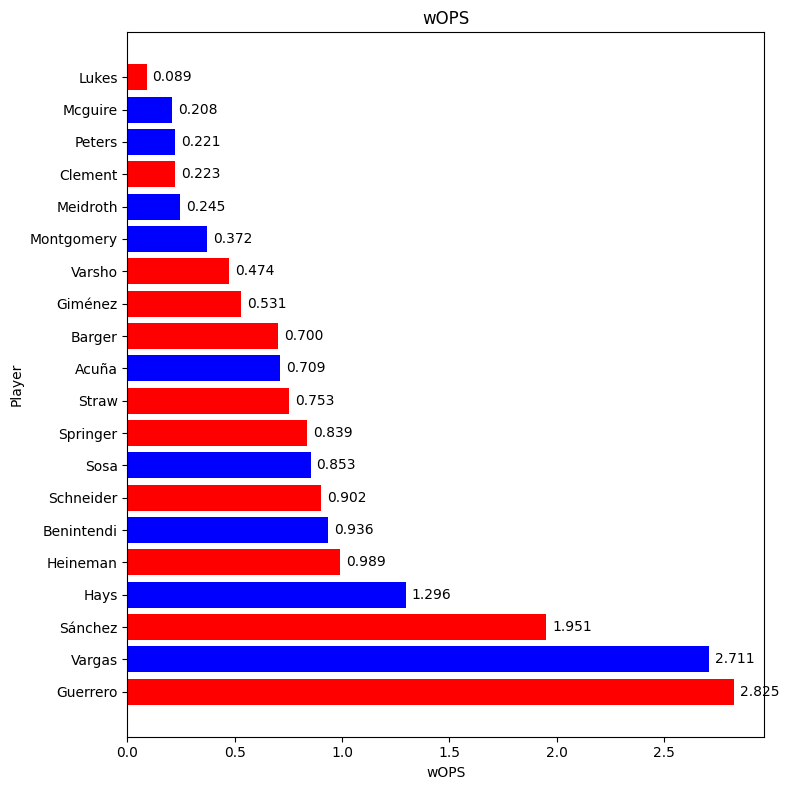

In [101]:
#Totals Graphs

#wOBA graph
sorted_batters = sorted(batter_info, key=lambda b: b['total_estimated_woba'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['total_estimated_woba'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOBA')
plt.ylabel('Player')
plt.title('Total Game wOBA')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#xSLG graph
sorted_batters = sorted(batter_info, key=lambda b: b['total_estimated_slg'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['total_estimated_slg'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('xSLG')
plt.ylabel('Player')
plt.title('Total Game xSLG')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#wOPS graph
sorted_batters = sorted(batter_info, key=lambda b: b['total_wops'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['total_wops'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]
plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOPS')
plt.ylabel('Player')
plt.title('Total Game wOPS')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#Graphs for Averages

#wOBA graph
sorted_batters = sorted(batter_info, key=lambda b: b['woba'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['woba'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOBA')
plt.ylabel('Player')
plt.title('wOBA')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#xSLG graph
sorted_batters = sorted(batter_info, key=lambda b: b['xslg'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['xslg'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('xSLG')
plt.ylabel('Player')
plt.title('xSLG')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#wOPS graph
sorted_batters = sorted(batter_info, key=lambda b: b['wops'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['wops'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]
plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOPS')
plt.ylabel('Player')
plt.title('wOPS')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()